#  분류 모델 평가 및 지표

-  이진 분류 지표의 경우 입력변수(Feature)를 사용하여 출력변수(Target)가 어떤 카테고리에 속하는지를 예측하는 문제이다. 스팸 탐지, 이미지 분류, 사기 탐지 등이 분류 문제에 해당한다.
- 분류의 평가방법은 실제 결과 데이터와 예측 결과 데이터가 얼마나 정확하고 오류가 적게 발생하는가에 기반하지만, 단순히 정확도만 가지고 판단했다가는 잘못된 평가 결과게 빠질 수 있다.


## 1. 이진 분류 지표 선택 기준
이진 분류 지표의 경우 각 지표별로 다른 특징을 갖기 때문에 적절한 지표를 선택하는 것이 중요하다.

(1) 오차행렬 = 오분류표=혼동행렬(Confusion Matrix)   
모델의 예측 결과를 실제 정답과 비교하여 정리한 2×2 표
클래스가 2개일 때, 다음과 같은 4가지 경우로 분류한다.  

![confusion](https://velog.velcdn.com/images/gangjoo/post/c6d9396b-15b1-4325-b429-50ca9fc3210c/image.png)

| 실제 / 예측          | Positive (1)        | Negative (0)        |
| ---------------- | ------------------- | ------------------- |
| **Positive (1)** | TP (True Positive)  | FN (False Negative) |
| **Negative (0)** | FP (False Positive) | TN (True Negative)  |


| 항목         | 의미                  |
| ---------- | ------------------- |
| TP (진짜 양성) | 실제 양성을 양성으로 예측      |
| TN (진짜 음성) | 실제 음성을 음성으로 예측      |
| FP (가짜 양성) | 실제는 음성인데 양성으로 잘못 예측 |
| FN (가짜 음성) | 실제는 양성인데 음성으로 잘못 예측 |

- TN는 예측값을 Negative 값 0으로 예측했고 실제값 역시 Negative 값 0
- FP는 예측값을 Positive 값 1로 예측했는데 실제 값은 Negative 값 0
- FN은 예측값을 Negative 값 0으로 예측했는데 실제 값은 Positive 값 1
- TP는 예측값을 Positive갑 1로 예측했는데 실제 값 역시 Positive 값 1


- False Positive는 1종 오류
- False Negative는 2종 오류

1종 오류와 2종 오류 중에서 어떤 것이 더 중요한지는, 의사결정자의 판단에 따라 다르다.

(2) 주요 분류 지표 (Classification Metrics)  
이진 분류에서 혼동행렬을 기반으로 도출되는 주요 지표:  

| 지표                    | 수식                                              | 의미                 |
| --------------------- | ----------------------------------------------- | ------------------ |
| **Accuracy (정확도)**    | (TP + TN) / (TP + TN + FP + FN)                 | 전체 중 정답 비율         |
| **Precision (정밀도)**   | TP / (TP + FP)                                  | 양성 예측 중 실제 양성 비율   |
| **Recall (재현율)**      | TP / (TP + FN)                                  | 실제 양성 중 모델이 잡아낸 비율 |
| **F1-Score**          | 2 × (Precision × Recall) / (Precision + Recall) | 정밀도와 재현율의 조화 평균    |
| **Specificity (특이도)** | TN / (TN + FP)                                  | 실제 음성 중 음성으로 맞춘 비율 |


| 상황                       | 중점 지표                           |
| ------------------------ | ------------------------------- |
| 양성 예측이 신중해야 할 때 (오진이 위험) | **Precision** (ex: 스팸 메일, 암 진단) |
| 놓치면 안 되는 양성을 잘 찾아야 할 때   | **Recall** (ex: 질병 검사, 이상탐지)    |
| Precision과 Recall이 모두 중요 | **F1 Score** 사용                 |
| 전체 성능이 중요할 때             | **Accuracy, ROC-AUC**           |


(3) ROC Curve와 AUC (Receiver Operating Characteristic)  

ROC 커브란?
X축: FPR (False Positive Rate) = FP / (FP + TN)  

Y축: TPR (True Positive Rate) = Recall = TP / (TP + FN)  

다양한 **분류 기준(threshold)**에 따라 모델이 얼마나 잘 구분하는지를 시각화한 곡선  

AUC (Area Under Curve)  
- ROC 곡선 아래 면적 값 (0 ~ 1)  
- 1에 가까울수록 분류 성능이 뛰어남
- 0.5면 랜덤 추측과 동일, 0.7 이상이면 양호한 모델

*** 분류 지표 선택 기준***

| 지표                          | 특징                       | 활용 상황            |
| --------------------------- | ------------------------ | ---------------- |
| **Confusion Matrix**        | 예측 결과를 TP/FN/FP/TN으로 세분화 | 전체적인 오류 유형 확인    |
| **Precision / Recall / F1** | 클래스 불균형 상황에 강함           | 예측 대상이 희귀할 때 중요  |
| **ROC Curve / AUC**         | 임계값 변화에 따른 전체 성능 시각화     | 모델 전체 성능 비교 시 유용 |


### 1. 정확도 (Accuracy)  
$정확도(Accuracy) = \frac{예측 결과가 동일한 데이터 건수 }{전체 예측데이터 건수}$

- 정확도는 직관적으로 모델 예측 성능을 나타내는 평가 지표이다.  
- 하지만 이진 분류의 경우 데이터의 구성에 따라 ML모델의 성능을 왜곡할 수 있기 때문에 정확도 수치 하나만 가지고 성능을 평가하지 않는다.

## 2. LogisticRegression  분류 알고리즘

LogisticRegression( )알고리즘의 penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None  


1. **penalty:**  
정규화 방법을 지정한다. 'l2'는 L2 정규화를 의미하며, 이는 가중치의 제곱합을 최소화하여 과적합을 방지하는 데 도움을 준다. 'l1'을 선택하면 L1 정규화를 사용하여 일부 가중치를 0으로 만들 수 있다. 'elasticnet'을 선택하면 L1과 L2 정규화를 혼합하여 사용할 수 있다.  
**2. dual:**  
이진 분류 문제에서 이중 문제를 해결할지를 결정한다. True로 설정하면 이중 문제를 해결하고, False로 설정하면 원래의 문제를 해결한다. 일반적으로 이진 분류에서는 False로 설정하는 것이 더 효율적이다.  
**3. tol:**  
수렴 기준을 설정합니다. 알고리즘이 수렴했다고 판단하는 기준으로, 기본값은 0.0001이다. 이 값이 작을수록 더 정밀한 수렴을 요구한다.  
**4. C:**  
정규화 강도를 조절하는 하이퍼파라미터이다. 값이 작을수록 정규화가 강해지고, 값이 클수록 정규화가 약해진다. 기본값은 1.0이다.  
**5. fit_intercept:**  
절편(intercept)을 모델에 포함할지를 결정한다. True로 설정하면 절편을 포함하고, False로 설정하면 절편을 포함하지 않는다. 기본값은 True이다.  
**6. intercept_scaling:**  
다중 클래스 문제에서 절편을 조정하는 데 사용된다. 기본값은 1이며, 이 값은 절편의 스케일을 조정하는 데 사용된다.  
**7. class_weight:**  
클래스의 가중치를 설정한다. None으로 설정하면 모든 클래스의 가중치가 동일하게 설정됩니다. 클래스 불균형이 있는 경우, 특정 클래스에 더 높은 가중치를 부여하여 모델이 해당 클래스를 더 잘 학습하도록 할 수 있다.
**8. random_state:**  
난수 생성기의 시드를 설정합니다. 동일한 시드를 사용하면 동일한 결과를 재현할 수 있다. 기본값은 None이다.  
**9. solver:**  
최적화 알고리즘을 선택한다. 'lbfgs', 'newton-cg', 'liblinear', 'sag', 'saga' 중 하나를 선택할 수 있다. 각 솔버는 서로 다른 특성과 성능을 가지므로 데이터셋에 따라 적절한 솔버를 선택하는 것이 중요하다.  
**10. max_iter:**      
알고리즘의 최대 반복 횟수를 설정한다. 기본값은 100이며, 이 값에 도달하기 전에 수렴하면 알고리즘이 종료된다.  
**11. multi_class:**  
다중 클래스 문제에서의 처리 방법을 설정한다. 'deprecated'는 더 이상 사용되지 않는 옵션이며, 대신 'ovr' (One-vs-Rest) 또는 'multinomial'을 사용할 수 있다.  
**12. verbose:**  
출력의 상세 정도를 설정한다. 0이면 출력이 없고, 1 이상의 값으로 설정하면 더 많은 정보가 출력된다.  
**13. warm_start:**  
이전에 학습한 모델을 재사용할지를 결정한다. True로 설정하면 이전 모델의 가중치를 초기값으로 사용하여 학습을 계속할 수 있다.  
**14. n_jobs:**  
병렬 처리를 위한 작업 수를 설정한다. None으로 설정하면 기본값이 사용되며, -1로 설정하면 모든 CPU 코어를 사용한다.  
**15. l1_ratio:**  
L1과 L2 정규화의 비율을 설정한다. 'elasticnet'을 사용할 때만 의미가 있으며, 기본값은 None이다.

## 3. load_breast_cancer
sklearn.datasets.load_breast_cancer는 유방암 진단 데이터를 포함한 유명한 이진 분류(Binary Classification) 문제용 데이터셋이다.  

- 위스콘신 유방암 진단(Wisconsin Diagnostic Breast Cancer, WDBC) 데이터셋
- 양성(Benign, B)과 악성(Malignant, M) 유방암 종양을 분류하는 이진 분류 문제
- 샘플 수: 569개
- 특성 수: 30개
- 타깃 클래스: 2개 (악성: 0, 양성: 1)

| 그룹 | 특성명 예시                                                                      | 설명                                 |
| -- | --------------------------------------------------------------------------- | ---------------------------------- |
| 1  | `radius_mean`, `radius_se`, `radius_worst`                                  | 종양의 평균 반지름, 표준오차, 최악 반지름           |
| 2  | `texture_mean`, `texture_se`, `texture_worst`                               | 조직의 거칠기(회색 강도 변화)                  |
| 3  | `perimeter_mean`, `perimeter_se`, `perimeter_worst`                         | 종양의 둘레 길이                          |
| 4  | `area_mean`, `area_se`, `area_worst`                                        | 종양의 면적                             |
| 5  | `smoothness_mean`, `smoothness_se`, `smoothness_worst`                      | 경계의 매끄러움 (국소 변화 정도)                |
| 6  | `compactness_mean`, `compactness_se`, `compactness_worst`                   | (둘레² / 면적 - 1.0): 종양이 얼마나 응축되어 있는지 |
| 7  | `concavity_mean`, `concavity_se`, `concavity_worst`                         | 종양 경계의 오목한 부분의 심각도                 |
| 8  | `concave points_mean`, `concave points_se`, `concave points_worst`          | 오목한 부분을 이루는 점들의 수                  |
| 9  | `symmetry_mean`, `symmetry_se`, `symmetry_worst`                            | 대칭성 정도                             |
| 10 | `fractal_dimension_mean`, `fractal_dimension_se`, `fractal_dimension_worst` | 경계의 복잡도 (프랙탈 차원)                   |


## 4. 혼동 행렬(Confusion matrix) 과 분류 지표 (Classification Metrics)
혼동 행렬은 실제값과 예측값을 시각적으로 비교하는 테이블로 분류 모델의 대략적인 성능을 평가하고, 분류 지료를 산출하는 도구로 활용된다.  

| 지표명 (Metric)              | 수식 (공식)                                                                                      | `sklearn` 함수                            |
| ------------------------- | -------------------------------------------------------------------------------------------- | --------------------------------------- |
| **Accuracy** (정확도)        | (TP + TN) / (TP + TN + FP + FN)                                                     | `sklearn.metrics.accuracy_score`        |
| **Precision** (정밀도)       | TP / (TP + FP)                                                                   | `sklearn.metrics.precision_score`       |
| **Recall** (재현율 / 민감도)    | TP / (TP + FN)                                                                    | `sklearn.metrics.recall_score`          |
| **F1 Score**              | 2 × (Precision × Recall) / (Precision + Recall) | `sklearn.metrics.f1_score`              |
| **Specificity** (특이도)     | TN / (TN + FP)                                                                   | 직접 계산 필요 (`confusion_matrix`)           |




```
# sklearn에서 사용하는 방법
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

accuracy_score(y_test, y_pred)
precision_score(y_test, y_pred)
recall_score(y_test, y_pred)
f1_score(y_test, y_pred)
confusion_matrix(y_test, y_pred)
roc_auc_score(y_test, y_prob)  # y_prob: 예측 확률
roc_curve(y_test, y_prob)
classification_report(y_test, y_pred)
```

In [ ]:
import sklearn

# [Windows에서 아래 코드를 실행하면 오류발생]:
# UnicodeDecodeError: 'cp949' codec can't decodeXXX
# model = LogisticRegression(max_iter=10000 )

# [해결방법]
# HTML 다이어그램 출력 기능을 끄고 텍스트로 표시
import platform
print(platform.system())
if platform.system()== 'Windows':
   sklearn.set_config(display='text')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, roc_auc_score, roc_curve, classification_report


# 1. 데이터 불러오기
data = load_breast_cancer()
X = data.data
y = data.target

target_names = data.target_names  # ['malignant', 'benign']

#print(X[:5])
print(dir(data))
#print(data.DESCR)
#print(data.feature_names)
print(data.target_names)
'''
| 용어            | 한글 해석   | 설명                                                                          |
| -------------   | ------- | --------------------------------------------------------------------------- |
| **malignant**   | 악성 (암)  | 빠르게 자라고 전이할 가능성이 높은 종양이나 질병. 보통 **암(Cancer)** 을 뜻함. 치료가 어렵고 생명에 위협이 될 수 있음. |
| **benign**      | 양성  (비암성) | 성장하긴 하지만 전이하지 않으며 비교적 **위험하지 않은 상태**. 수술 등으로 완치 가능한 경우가 많음.                 |

- malignant: 악성 종양 (암) → 0 또는 Negative Class
- benign: 양성 종양 (비암성) → 1 또는 Positive Class
'''

# 2. 데이터 분할 (학습 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 모델 학습 (로지스틱 회귀)
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# 4. 예측 (클래스 예측 및 확률 예측)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # 양성 클래스(1)의 확률
#y_prob = model.predict_proba(X_test)[:5, :]
#print(f'y_pred: {y_pred}')
#print(f'y_prob: {y_prob}')


# 6. 출력
print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 7. 평가지표 계산
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("평가 지표")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")


['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']
['malignant' 'benign']
Confusion Matrix
[[39  4]
 [ 1 70]]
평가 지표
Accuracy  : 0.9561
Precision : 0.9459
Recall    : 0.9859
F1 Score  : 0.9655
ROC AUC   : 0.9977


각 행은 실제 클래스, 각 열은 예측된 클래스입니다.

- **클래스 0:** TP = 36,  FN = 4
- **클래스 1:** TP = 1,   FN = 70

In [ ]:
# 1. average=None (클래스별 개별)
print("average=None (클래스별 출력)")
print("Precision:", precision_score(y_test, y_pred, average=None))
print("Recall   :", recall_score(y_test, y_pred, average=None))
print("F1 Score :", f1_score(y_test, y_pred, average=None))
print()

# 2. average='micro'
print("average='micro'")
print("Precision:", precision_score(y_test, y_pred, average='micro'))
print("Recall   :", recall_score(y_test, y_pred, average='micro'))
print("F1 Score :", f1_score(y_test, y_pred, average='micro'))
print()

# 3. average='macro'
print("average='macro'")
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall   :", recall_score(y_test, y_pred, average='macro'))
print("F1 Score :", f1_score(y_test, y_pred, average='macro'))
print()

# 4. average='weighted'
print("average='weighted'")
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))
print()

# 5. 전체 classification_report
print("Classification Report")
# target_names옵션을 설정하지 않으면 0과 1로 표시된다.
print(classification_report(y_test, y_pred))
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_names))

0. average='binary' (default)
   - positive label을 1로 간주하고 계산한다.
   - y_true에 0과 1 두 개 클래스만 있어야 한다.

1. average=None (클래스별 성능 개별 출력)

| 클래스               | Precision | Recall | F1-score | Support |
| ----------------- | --------- | ------ | -------- | ------- |
| **0 (malignant)** | 0.97      | 0.91   | 0.94     | 43      |
| **1 (benign)**    | 0.95      | 0.99   | 0.97     | 71      |

- 각 클래스별로 정밀도, 재현율, F1-score를 개별적으로 계산하여 보여준다.
- 모델이 클래스 0 (악성 종양)을 상대적으로 덜 잘 맞추고 있다는 것을 파악할 수 있다.

2. average='micro' (전체 기준 - 샘플 단위의 합)  
- micro 평균은 모든 TP, FP, FN을 전 클래스 기준으로 합산한 뒤 계산한다.
- 이 경우 정확도(Accuracy) = Precision = Recall = F1-score가 된다.
- 총 정답 수: TP(전체 맞춤 수) = 0 클래스에서 39개 + 1 클래스에서 70개 = 109
- 전체 샘플 수: 114
- 따라서:    Accuracy = Precision = Recall = F1 = 109 / 114 ≈ 0.9561  

3. average='macro' (단순 평균)  
- 클래스별 점수를 동일한 비중으로 평균함
  Macro Precision = (0.97 + 0.95) / 2 = 0.96  
  Macro Recall    = (0.91 + 0.99) / 2 = 0.95  
  Macro F1-score  = (0.94 + 0.97) / 2 = 0.955 ≈ 0.95  

- 클래스 0과 1의 비중이 같다고 가정하고 평균 내기 때문에, 클래스 불균형이 있는 경우에는 왜곡이 있을 수 있다.

4. average='weighted' (샘플 수 기반 가중 평균)  
-  각 클래스의 점수에 해당 클래스의 샘플 개수(Support)를 곱해서 평균
  Weighted Precision = (0.97×43 + 0.95×71) / 114 ≈ 0.958    
  Weighted Recall    = (0.91×43 + 0.99×71) / 114 ≈ 0.961  
  Weighted F1-score  = (0.94×43 + 0.97×71) / 114 ≈ 0.961  

- 실제 출력값은 모두 반올림되어 0.96으로 나옴

- 데이터 불균형을 고려한 평균이므로, 실전에서 가장 신뢰도 있는 지표 중 하나임

5. average 옵션 요약

| 평균 방식      | 설명                    | 특징               | 언제 사용하면 좋은가?                 |
| ---------- | --------------------- |------------ | ---------------------------- |
| `None`     | 클래스별 개별 지표 확인         |  `array` 형태       | 특정 클래스 성능 비교 시               |
| `micro`    | 전체 샘플 기준으로 정밀도/재현율 계산 | 불균형 데이터에 취약      | 다중 클래스, 불균형 무시하고 전체 성능 확인 시  |
| `macro`    | 클래스별 단순 평균            | 클래스 중요도 균일할 때 사용 |클래스 간 균형 평가 시                |
| `weighted` | 클래스별 가중 평균            | 불균형 데이터에 적합      |**불균형 데이터에서의 전체 성능 평가** 시 유리 |





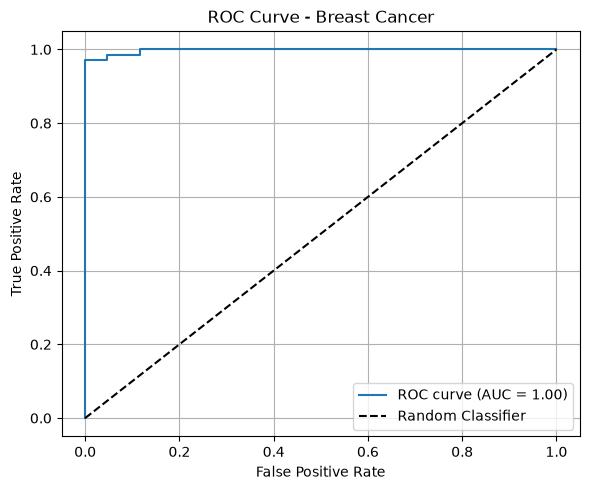

In [2]:

# 7. ROC Curve 시각화
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Breast Cancer')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

불균형한 이진 분류로 만들기 위해 숫자 '7'만 True 나머지 숫자는 False로 설정

- 마찬가지로 fit은 아무것도 하지 않음
- predict에서는 무조건 0을 반환함
- 모든 예측을 다 0으로 하는 것! (모두 7이 아닌 다른 숫자라고 예측)
- 당연히 모델로서 말이 안 되는데 이것의 정확도를 측정

In [ ]:

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

class MyFakeClassifier(BaseEstimator):
    def fit(self,X,y):
        pass

    # 입력값으로 들어오는 X 데이터 셋의 크기만큼 모두 0값으로 만들어서 반환
    def predict(self,X):
        return np.zeros( (len(X), 1) , dtype=bool)

# 사이킷런의 내장 데이터 셋인 load_digits( )를 이용하여 MNIST 데이터 로딩
digits = load_digits()

print(digits.data)
print("### digits.data.shape:", digits.data.shape)
print(digits.target)
print("### digits.target.shape:", digits.target.shape)

In [ ]:
print(digits.target)
#숫자가 7인 경우 True이고 나머지는 False이므로, 이를  1과 0으로 변환하기 위해서 astype(int)로 한 것이다.
y = (digits.target == 7 ).astype(int)
print(len(y))
# 7이면 1, 7이 아니면 0
#0    1618
#1     179
print(pd.Series(y).value_counts())


X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=11)
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())


# MyFakeClassifier로 학습/예측/정확도 평가
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)

fakepred = fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는:{:.3f}'.format(accuracy_score(y_test, fakepred)))

cf = confusion_matrix(y_test, fakepred)
print('confusion_matrix')
print(cf)


- 모든 예측을 0으로 했지만, 0 (7이 아닌 숫자)이 1 (숫자 7)보다 훨씬 많은 불균형 데이터였기 때문에, 정확도가 무려 90%가 나왔다.

- 이렇게 두 가지 예제로 불균형 데이터에서 정확도의 성능 평가지표로서 한계를 보였다